# Dive Deeper in Signal Transformation based on EEG Signals

The EEG dataset used in this project is collected by Boyu Qian for a attention study. The dataset contains RAW data of 16 channels for 40 minutes of a participant, recording their EEG signals when they are performing a typing task. In the control group, the participant was asked to type for 15 min and meditate for 10 min， then continue to type for another 15 min. For the experimental group, the participant was asked to watch Tiktok videos rather than meditation. The rest parts were the same. The data we used here is from control group. First, we want to look at the data in time domain, and then analyze it in frequency domain to see if the participant was showed a different power pattern before and after the rest. The data is saved a CSV file.

Before diving into the exploration of the EEG data, we want to specify the channels that we are looking at. For this project, we want to focus on researching frontal lobe. It is important for voluntary movement, expressive language and for managing higher level executive functions. According to 10-20 system map, we can find that electrodes Fp1 and Fp1 are the closest to frontal lobe, corresponding to channel 1 and 2. So in this project we will use the data from channel 1 and 2.

In [ ]:
from IPython.display import Image 
Image(url="map.jpg", width=300, height=300) 

In [ ]:
# # Mount drive

# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# # Unmount drive

# from google.colab import drive
# drive.flush_and_unmount()
# print('All changes made in this colab session should now be visible in Drive.')

## Data Preparation

### Why Data Preparation Matters

EEG signals are inherently noisy and complex. Raw EEG data often contains various artifacts and interferences that can significantly affect the quality of our analysis. Proper data preparation is crucial because:

1. **Loading the EEG Data**
   - The code reads EEG data from a CSV file using pandas
   - The data is tab-separated and initially has no header
   - We select the first 17 columns which contain the relevant EEG channels

2. **Column Naming**
   - Assigns meaningful names to the columns:
     - First column: 'Time'
     - Remaining 16 columns: EEG1 through EEG16, representing different EEG channels

3. **Timestamp Generation**
   - Creates a 'Timestamp' column based on the sampling rate (125 Hz)
   - Each timestamp represents the time in seconds from the start of recording
   - Reorganizes the columns to place the Timestamp as the first column



In [ ]:
import pandas as pd

# df_orig = pd.read_csv('/content/drive/MyDrive/bme671_project/BrainFlow-RAW_08-part1_0.csv', sep='\t', header=None)
df_orig = pd.read_csv('BrainFlow-RAW_08-part1_0.csv', sep='\t', header=None)
df_orig = df_orig.iloc[:, :17]
df_orig.head()


FileNotFoundError: [Errno 2] No such file or directory: 'BrainFlow-RAW_08-part1_0.csv'

In [ ]:
df_orig.columns = ['Time', 'EEG1', 'EEG2', 'EEG3', 'EEG4', 'EEG5', 'EEG6', 'EEG7', 'EEG8', 'EEG9', 'EEG10', 'EEG11', 'EEG12', 'EEG13', 'EEG14', 'EEG15', 'EEG16']
df_orig

,Time,EEG1,EEG2,EEG3,EEG4,EEG5,EEG6,EEG7,EEG8,EEG9,EEG10,EEG11,EEG12,EEG13,EEG14,EEG15,EEG16
0,0.0,-12638.436274,-20243.326753,-54386.219905,-43826.853493,-45154.725928,-27081.686506,-93750.011176,-21684.746049,-20794.587826,-27171.071133,-55544.487303,-35283.972059,-23299.972510,-11030.697647,-82106.741620,-93750.011176
1,2.0,-32189.395391,-40244.941741,-86647.319692,-93284.223173,-64990.803896,-31638.246076,-178849.159640,-31071.338781,-33219.833162,-45648.520666,-113125.374988,-67203.961874,-36881.942973,-6640.837388,-109383.692966,-187500.022352
2,4.0,-35768.803748,-41673.017046,-125971.928355,-85544.954007,-106612.903668,-69298.521495,-187500.022352,-53528.605822,-44746.292501,-58981.917379,-112561.239309,-73266.626688,-48839.880388,-20294.512247,-118202.283168,-187500.022352
3,6.0,-26623.252228,-40227.574435,-96071.016320,-90567.011007,-76290.705954,-41564.633437,-182029.164675,-36146.212953,-49531.689230,-48173.463127,-108395.343530,-65529.302124,-62561.079867,-38970.467624,-136762.836488,-187500.022352
4,8.0,-37669.283172,-41086.149643,-104982.679186,-90151.290912,-83530.793611,-48589.250277,-184312.708296,-41722.526160,-30435.029320,-52429.592899,-115742.250173,-72042.242830,-28661.641915,4566.662558,-98054.599530,-187500.022352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308873,166.0,-7051.036602,-39472.532507,-75190.575444,-83466.197069,-35213.072325,-17881.037936,-146198.111319,-17444.441312,-46739.732830,-48700.383151,-89715.208377,-70182.354174,-48499.910355,-17703.006292,-52651.769239,-187500.022352
308874,168.0,-7391.587781,-40050.392157,-72880.835579,-83273.726198,-32704.401935,-15662.716706,-143819.304564,-15834.847490,-47248.056203,-48489.986180,-89401.993382,-69963.552947,-49891.462909,-19538.889174,-56369.132563,-187500.022352
308875,170.0,-6923.408142,-39652.531106,-73409.476687,-83763.631733,-32271.538052,-14830.158929,-143089.050721,-15726.888564,-46684.769891,-48554.113335,-89612.859739,-69876.962289,-47753.719718,-16422.921887,-50841.702621,-187500.022352
308876,172.0,-7296.168184,-39665.070434,-74894.437181,-83140.062766,-35552.975303,-18462.742086,-147094.349217,-17588.341843,-47082.116852,-48580.175469,-89559.640236,-70221.581485,-49849.084002,-19636.655705,-56076.056489,-187500.022352


In [ ]:
df_orig['Timestamp'] = df_orig.index * (1 / 125)

# Switch the position of the 1st and last columns
cols = list(df_orig.columns)
cols[0], cols[-1] = cols[-1], cols[0]
df_orig = df_orig[cols]

df_orig

,Timestamp,EEG1,EEG2,EEG3,EEG4,EEG5,EEG6,EEG7,EEG8,EEG9,EEG10,EEG11,EEG12,EEG13,EEG14,EEG15,EEG16,Time
0,0.000,-12638.436274,-20243.326753,-54386.219905,-43826.853493,-45154.725928,-27081.686506,-93750.011176,-21684.746049,-20794.587826,-27171.071133,-55544.487303,-35283.972059,-23299.972510,-11030.697647,-82106.741620,-93750.011176,0.0
1,0.008,-32189.395391,-40244.941741,-86647.319692,-93284.223173,-64990.803896,-31638.246076,-178849.159640,-31071.338781,-33219.833162,-45648.520666,-113125.374988,-67203.961874,-36881.942973,-6640.837388,-109383.692966,-187500.022352,2.0
2,0.016,-35768.803748,-41673.017046,-125971.928355,-85544.954007,-106612.903668,-69298.521495,-187500.022352,-53528.605822,-44746.292501,-58981.917379,-112561.239309,-73266.626688,-48839.880388,-20294.512247,-118202.283168,-187500.022352,4.0
3,0.024,-26623.252228,-40227.574435,-96071.016320,-90567.011007,-76290.705954,-41564.633437,-182029.164675,-36146.212953,-49531.689230,-48173.463127,-108395.343530,-65529.302124,-62561.079867,-38970.467624,-136762.836488,-187500.022352,6.0
4,0.032,-37669.283172,-41086.149643,-104982.679186,-90151.290912,-83530.793611,-48589.250277,-184312.708296,-41722.526160,-30435.029320,-52429.592899,-115742.250173,-72042.242830,-28661.641915,4566.662558,-98054.599530,-187500.022352,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308873,2470.984,-7051.036602,-39472.532507,-75190.575444,-83466.197069,-35213.072325,-17881.037936,-146198.111319,-17444.441312,-46739.732830,-48700.383151,-89715.208377,-70182.354174,-48499.910355,-17703.006292,-52651.769239,-187500.022352,166.0
308874,2470.992,-7391.587781,-40050.392157,-72880.835579,-83273.726198,-32704.401935,-15662.716706,-143819.304564,-15834.847490,-47248.056203,-48489.986180,-89401.993382,-69963.552947,-49891.462909,-19538.889174,-56369.132563,-187500.022352,168.0
308875,2471.000,-6923.408142,-39652.531106,-73409.476687,-83763.631733,-32271.538052,-14830.158929,-143089.050721,-15726.888564,-46684.769891,-48554.113335,-89612.859739,-69876.962289,-47753.719718,-16422.921887,-50841.702621,-187500.022352,170.0
308876,2471.008,-7296.168184,-39665.070434,-74894.437181,-83140.062766,-35552.975303,-18462.742086,-147094.349217,-17588.341843,-47082.116852,-48580.175469,-89559.640236,-70221.581485,-49849.084002,-19636.655705,-56076.056489,-187500.022352,172.0


# Time Frequency Analysis

### Understanding the Signal in Time Domain
Before diving into time-frequency analysis, we need to understand our signal in its raw form:
- Visualize the EEG signal over time
- Identify any obvious patterns or artifacts
- Scale the signal appropriately for analysis
- Remove outliers that might affect our analysis

### Frequency Domain Analysis as a Foundation
To understand the frequency content of our signal:
1. Perform FFT (Fast Fourier Transform) to see the overall frequency distribution
2. Focus on the positive frequencies (0 to Nyquist frequency)
3. Normalize the amplitude spectrum for proper scaling
4. This gives us a baseline understanding of what frequencies are present in our signal

### Power Spectrum Analysis
Power spectrum analysis is crucial for time-frequency analysis because:
- It shows how signal power is distributed across frequencies
- Helps identify dominant frequency bands
- Provides a reference for interpreting time-frequency results

To create a power spectrum:
1. Use spectrogram with appropriate window size (e.g., 256 samples)
2. Include overlap (e.g., 128 samples) for smoother transitions
3. Convert to dB scale for better visualization
4. Use appropriate colormap to highlight power variations

### Time-Frequency Analysis Implementation
To implement time-frequency analysis:
1. Choose appropriate parameters:
   - Window size (nperseg) affects frequency resolution
   - Overlap (noverlap) affects time resolution
   - Sampling rate determines frequency range

2. Process the signal:
   - Convert to power spectral density
   - Scale appropriately for visualization

3. Visualize the results:
   - Use colormap to represent power intensity
   - Label axes appropriately
   - Include colorbar for power reference

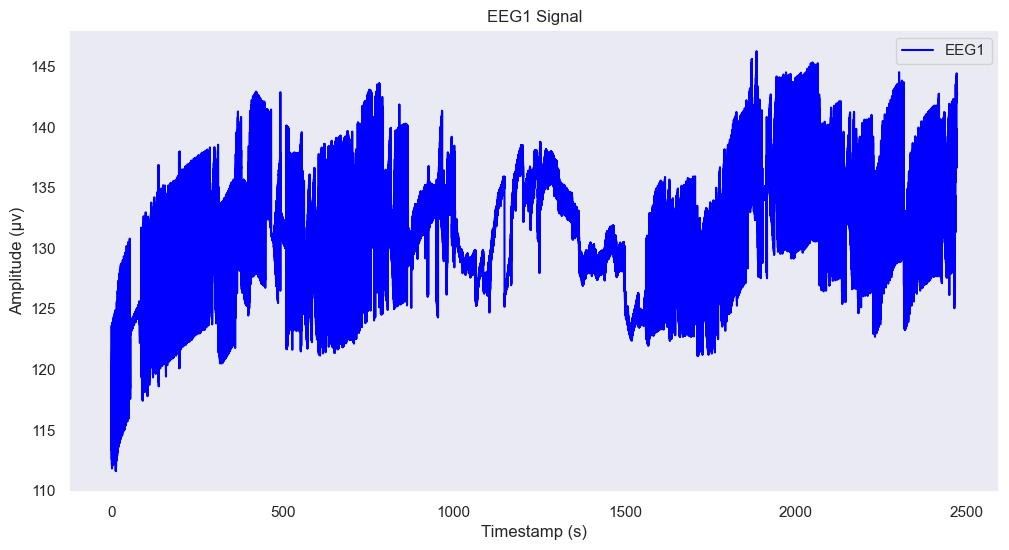

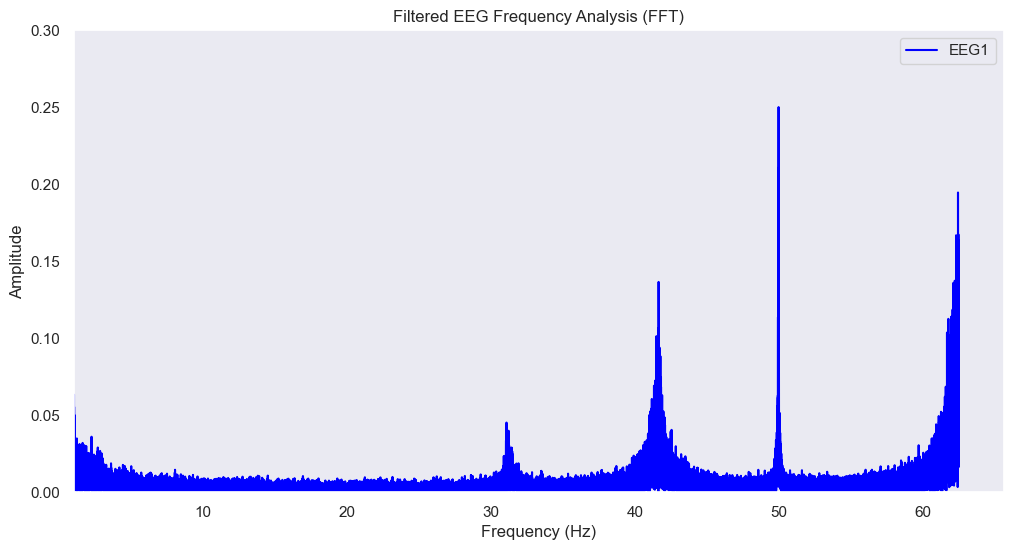

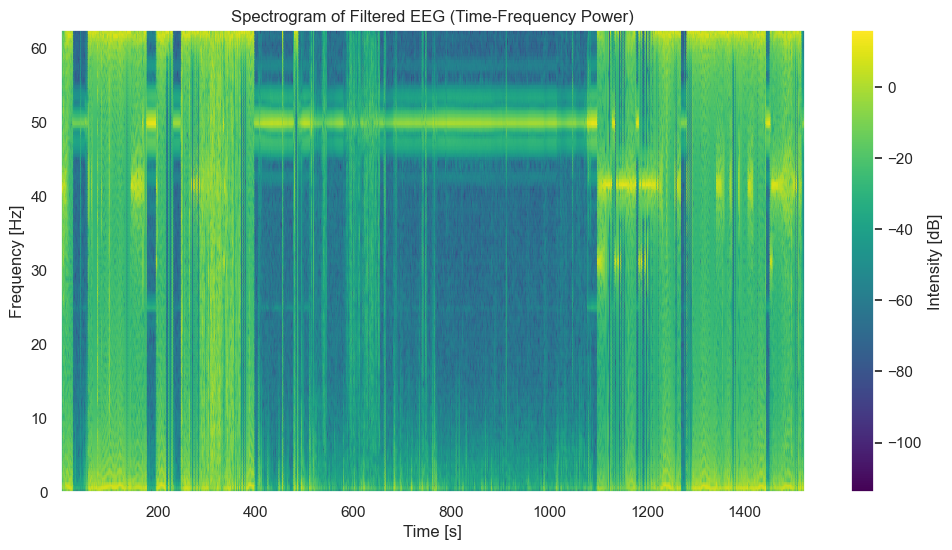

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.signal import butter, filtfilt, iirnotch, spectrogram
from scipy.fft import fft

fs = 125.0  # Sampling frequency in Hz

df_chan1 = df_orig[['Timestamp', 'EEG1']].copy()
df_chan1.columns = ['Timestamp', 'EEG']
df_chan1['EEG'] = df_chan1['EEG']/(1000)+150

# remove the outliers with difference of 10k
df_chan1 = df_chan1[df_chan1['EEG'].diff().abs() < 10]

# plot
sns.set(style="darkgrid")
plt.figure(figsize=(12, 6))
plt.plot(df_chan1['Timestamp'], df_chan1['EEG'], label='EEG1', color='blue')
plt.title('EEG1 Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (μv)')
plt.legend()
plt.grid()
plt.show()

# --- FFT-based Frequency Analysis ---
# Calculate the FFT
# Convert the pandas Series to a NumPy array using .values
fft_result = fft(df_chan1['EEG'].values)
n = len(df_chan1['EEG']) # n is still the length of the original data
frequencies = np.fft.fftfreq(n, d=1/fs)

# Take the magnitude of the FFT and consider only the positive frequencies
magnitude_spectrum = np.abs(fft_result)[:n//2]
positive_frequencies = frequencies[:n//2]

# Plot the magnitude spectrum
plt.figure(figsize=(12, 6))

# Normalize by n/2 for amplitude spectrum
plt.plot(positive_frequencies, 2/n * magnitude_spectrum, label='EEG1', color='blue')
plt.title('Filtered EEG Frequency Analysis (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(1)
plt.ylim(0, 0.3)
plt.legend()
plt.grid()
plt.show()

# --- Time-Frequency Power Spectrum Analysis (Spectrogram) ---
# Perform time-frequency analysis using spectrogram
# Use the filtered data
f_spec, t_spec, Sxx = spectrogram(df_chan1['EEG'].values, fs=fs, nperseg=256, noverlap=128)

plt.figure(figsize=(12, 6))
# Plot the spectrogram (time-frequency power)
# Using 10*log10(Sxx) for power spectral density in dB
plt.pcolormesh(t_spec + df_chan1['Timestamp'].iloc[0], f_spec, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis') # Added cmap for color scheme
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of Filtered EEG (Time-Frequency Power)')
plt.colorbar(label='Intensity [dB]')
# Optional: Limit frequency range if needed, e.g., plt.ylim([0, 60])
plt.show()

# # Perform time-frequency analysis using spectrogram
# f, t, Sxx = spectrogram(df_chan1['EEG'], fs=125, nperseg=256, noverlap=128)
# plt.figure(figsize=(12, 6))
# plt.pcolormesh(t, f, 10 * np.log10(Sxx), cmap='plasma', shading='gouraud')  # Changed colorset to 'plasma'
# plt.ylabel('Frequency [Hz]')
# plt.xlabel('Time [s]')
# plt.title('Spectrogram of EEG1')
# plt.colorbar(label='Intensity [dB]')
# plt.show()

# # plot for frequency analysis， x-axis is frequency, y-axis is amplitude
# plt.figure(figsize=(12, 6))
# plt.plot(f, 10 * np.log10(Sxx.mean(axis=1)), label='EEG1', color='blue')
# plt.title('EEG1 Frequency Analysis')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Amplitude (dB)')
# plt.legend()
# plt.grid()
# plt.show()


# Bandpass Filter

## Why Do We Need Filtering?

Before performing time-frequency analysis, we need to ensure our signal is clean and contains only the frequencies of interest. EEG signals typically contain:
- Physiological artifacts (e.g., muscle activity, eye movements)
- Environmental noise (e.g., power line interference)
- Unwanted frequency components

## Bandpass Filtering: The First Step

Bandpass filtering is essential because:
1. EEG signals of interest typically lie within 1-60 Hz
2. Lower frequencies (<1 Hz) often contain drift and movement artifacts
3. Higher frequencies (>62.5 Hz) usually contain noise and muscle artifacts

To implement bandpass filtering:
1. Define filter parameters:
   - Lower cutoff frequency (1 Hz)
   - Upper cutoff frequency (62.5 Hz)
   - Filter order (affects roll-off steepness)
   - Sampling frequency (must be >2x highest frequency)

2. Design the filter:
   - Use Butterworth filter for flat passband
   - Implement zero-phase filtering to avoid phase distortion
   - Choose appropriate filter order for desired roll-off

## Notch Filtering: Removing Power Line Interference

After bandpass filtering, we often need to remove power line interference:
1. Power line noise typically occurs at 50 (US)/60 (China) Hz
2. Notch filter specifically targets this frequency

## Visualizing the Results

To verify our filtering:
1. Plot original vs. filtered signal
2. Compare frequency content before and after filtering

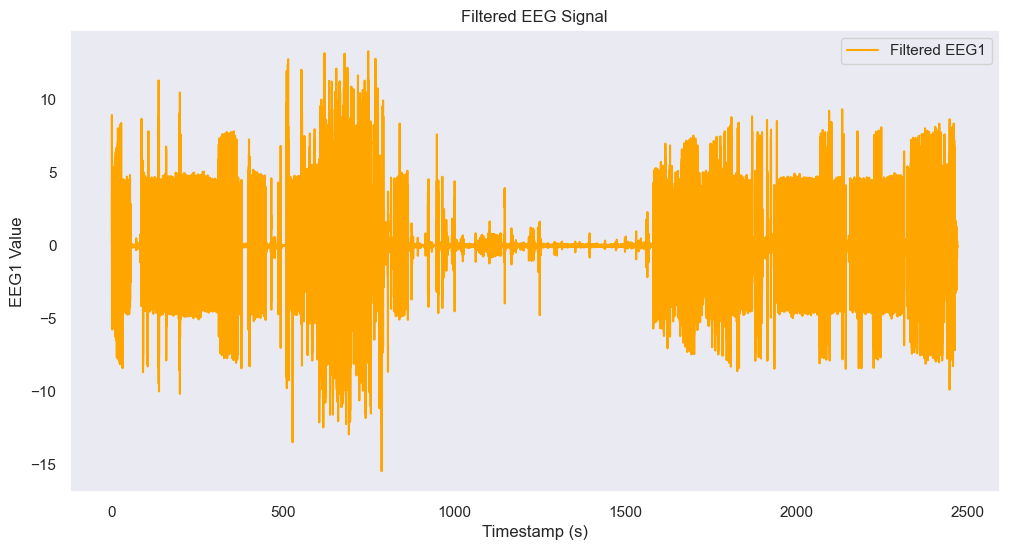

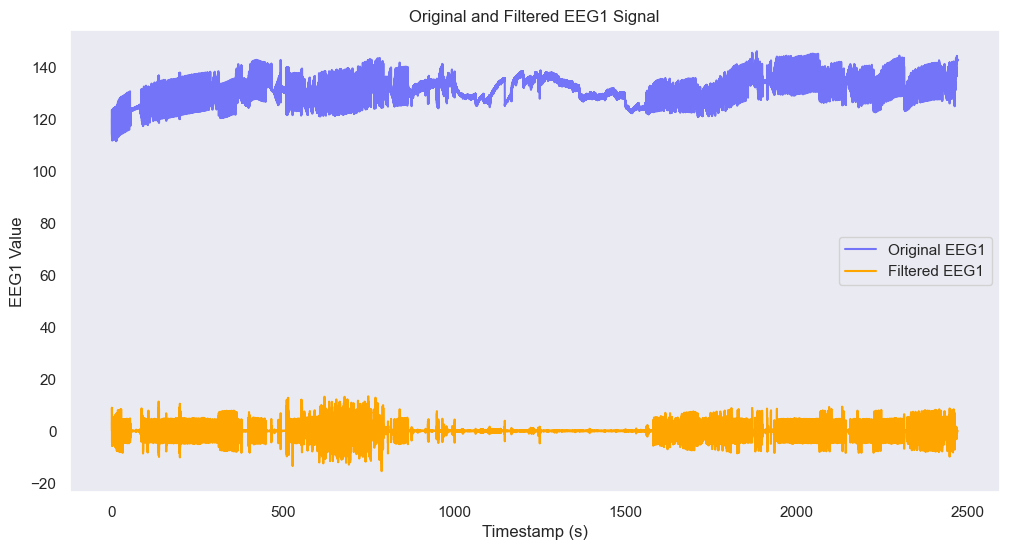

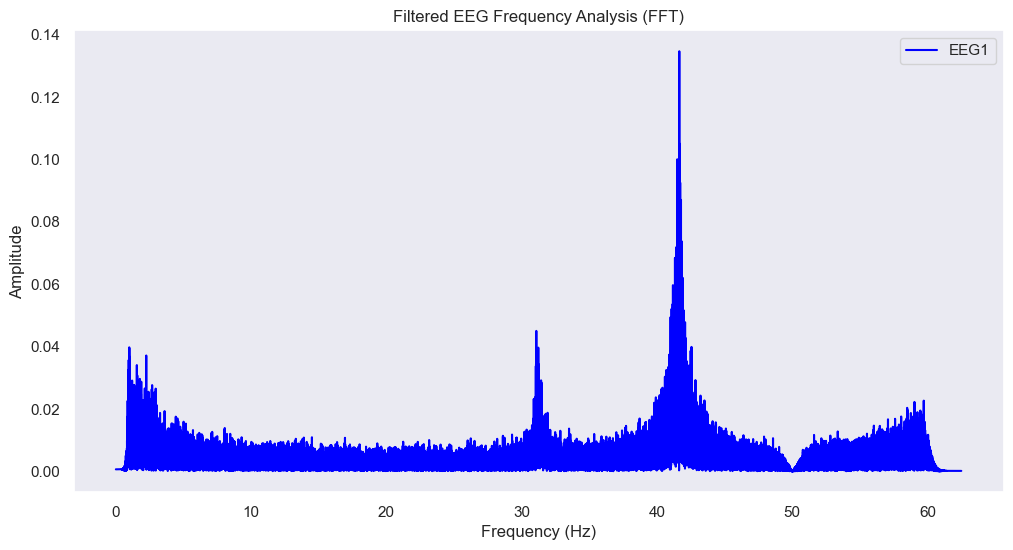

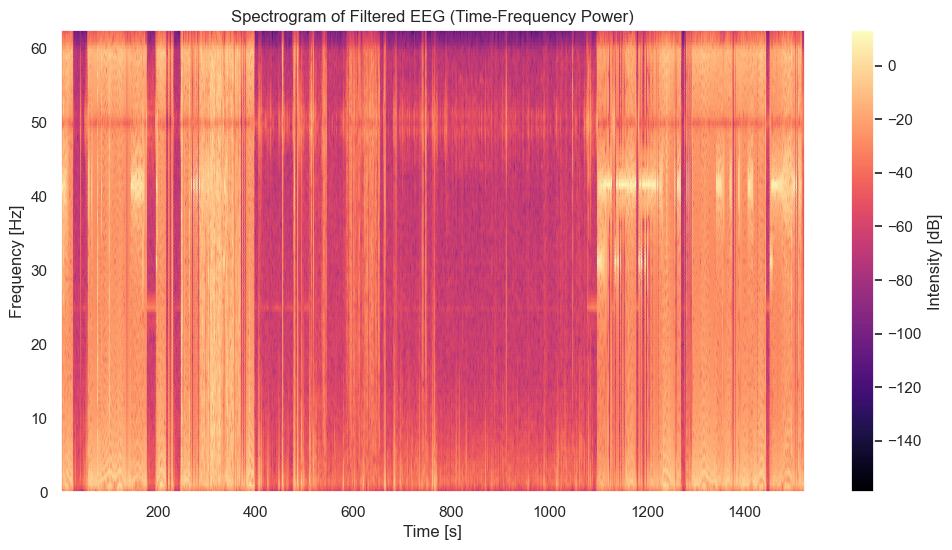

In [12]:
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch, spectrogram
from scipy.fft import fft
import matplotlib.pyplot as plt
import pandas as pd # Assuming df_chan1 is a pandas DataFrame

# Assuming df_chan1 is already loaded and contains 'Timestamp' and 'EEG' columns
# Example:
# data = {'Timestamp': np.linspace(0, 10, 1000), 'EEG': np.sin(2 * np.pi * 10 * np.linspace(0, 10, 1000)) + 0.5 * np.sin(2 * np.pi * 50 * np.linspace(0, 10, 1000)) + np.random.randn(1000)}
# df_chan1 = pd.DataFrame(data)


def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def notch_filter(data, f0, Q, fs):
    b, a = iirnotch(f0, Q, fs)
    y = filtfilt(b, a, data)
    return y

# Bandpass filter parameters
lowcut = 1.0  # Lower cutoff frequency in Hz
highcut = 60.0  # Upper cutoff frequency in Hz (must less than FS/2)
fs = 125.0  # Sampling frequency in Hz

# Apply bandpass filter
df_chan1['EEG_filtered'] = bandpass_filter(df_chan1['EEG'], lowcut, highcut, fs, order=5)

# Notch filter parameters
f0 = 50.0  # Frequency to be removed from signal (Hz)
Q = 30.0  # Quality factor
df_chan1['EEG_filtered'] = notch_filter(df_chan1['EEG_filtered'], f0, Q, fs)

# Plot the filtered signal
plt.figure(figsize=(12, 6))
plt.plot(df_chan1['Timestamp'], df_chan1['EEG_filtered'], label='Filtered EEG1', color='orange')
plt.title('Filtered EEG Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('EEG1 Value')
plt.legend()
plt.grid()
plt.show()

# Plot the original and filtered signals together
plt.figure(figsize=(12, 6))
plt.plot(df_chan1['Timestamp'], df_chan1['EEG'], label='Original EEG1', color='blue', alpha=0.5)
plt.plot(df_chan1['Timestamp'], df_chan1['EEG_filtered'], label='Filtered EEG1', color='orange')
plt.title('Original and Filtered EEG1 Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('EEG1 Value')
plt.legend()
plt.grid()
plt.show()

# --- FFT-based Frequency Analysis ---
# Calculate the FFT
# Convert the pandas Series to a NumPy array using .values
fft_result = fft(df_chan1['EEG_filtered'].values)
n = len(df_chan1['EEG_filtered']) # n is still the length of the original data
frequencies = np.fft.fftfreq(n, d=1/fs)

# Take the magnitude of the FFT and consider only the positive frequencies
magnitude_spectrum = np.abs(fft_result)[:n//2]
positive_frequencies = frequencies[:n//2]

# Plot the magnitude spectrum
plt.figure(figsize=(12, 6))
# Normalize by n/2 for amplitude spectrum
plt.plot(positive_frequencies, 2/n * magnitude_spectrum, label='EEG1', color='blue')
plt.title('Filtered EEG Frequency Analysis (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim()
plt.legend()
plt.grid()
plt.show()

# Note: FFT provides the frequency content of the entire signal at once.
# It doesn't provide time-varying frequency information like a spectrogram.

# --- Time-Frequency Power Spectrum Analysis (Spectrogram) ---
# Perform time-frequency analysis using spectrogram
# Use the filtered data
f_spec, t_spec, Sxx = spectrogram(df_chan1['EEG_filtered'].values, fs=fs, nperseg=256, noverlap=128)

plt.figure(figsize=(12, 6))
# Plot the spectrogram (time-frequency power)
# Using 10*log10(Sxx) for power spectral density in dB
plt.pcolormesh(t_spec + df_chan1['Timestamp'].iloc[0], f_spec, 10 * np.log10(Sxx), shading='gouraud', cmap='magma') # Added cmap for color scheme
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of Filtered EEG (Time-Frequency Power)')
plt.colorbar(label='Intensity [dB]')
# Optional: Limit frequency range if needed, e.g., plt.ylim([0, 60])
plt.show()

# Note: The FFT plot shows the average frequency content over the entire signal.
# The Spectrogram plot shows how the frequency content changes over time.

In [88]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

# Assuming df_chan1['EEG_filtered'] contains your filtered EEG data

# Define wavelet and decomposition level
wavelet = 'db4'  # Example wavelet, you can experiment with others
level = 4  # Decomposition level

# Perform wavelet decomposition
coeffs = pywt.wavedec(df_chan1['EEG_filtered'], wavelet, level=level)

# Reconstruct signals for different frequency bands
# (Adjust frequency ranges based on your data and wavelet)
# Delta (0.5-4 Hz)
delta_coeffs = [None, None, None, None, coeffs[4]]  # Reconstruct with D1
delta_signal = pywt.waverec(delta_coeffs, wavelet)[:len(df_chan1['Timestamp'])]

# Theta (4-8 Hz)
theta_coeffs = [None, None, None, coeffs[3], None] # Reconstruct with D2
theta_signal = pywt.waverec(theta_coeffs, wavelet)[:len(df_chan1['Timestamp'])]

# Alpha (8-12 Hz)
alpha_coeffs = [None, None, coeffs[2], None, None]  # Reconstruct with D3
alpha_signal = pywt.waverec(alpha_coeffs, wavelet)[:len(df_chan1['Timestamp'])]

# Beta (12-30 Hz)
beta_coeffs = [None, coeffs[1], None, None, None]  # Reconstruct with D4
beta_signal = pywt.waverec(beta_coeffs, wavelet)[:len(df_chan1['Timestamp'])]

# Gamma (30+ Hz)
gamma_coeffs = [coeffs[0], None, None, None, None]  # Reconstruct with A4
gamma_signal = pywt.waverec(gamma_coeffs, wavelet)[:len(df_chan1['Timestamp'])]

# Plot the reconstructed signals for each frequency band
plt.figure(figsize=(12, 6))
plt.plot(df_chan1['Timestamp'], delta_signal, label='Delta', color='blue')
plt.plot(df_chan1['Timestamp'], theta_signal, label='Theta', color='green')
plt.plot(df_chan1['Timestamp'], alpha_signal, label='Alpha', color='orange')
plt.plot(df_chan1['Timestamp'], beta_signal, label='Beta', color='red')
plt.plot(df_chan1['Timestamp'], gamma_signal, label='Gamma', color='purple')

plt.title('Reconstructed EEG Signals for Different Frequency Bands')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

ValueError: At least one coefficient parameter must be specified.

In [86]:
pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np

def haar_wavelet_transform(data, level):
    """
    Performs a Haar wavelet transform up to a specified level.

    Args:
        data: Input 1D data array.
        level: The number of decomposition levels.

    Returns:
        The wavelet coefficients at each level.
    """
    coefficients = [data.copy()]  # Initialize with original data

    for _ in range(level):
        n = len(coefficients[-1])
        if n % 2 != 0:
            # Pad with zeros if length is not even
            coefficients[-1] = np.append(coefficients[-1], 0)
        a = (coefficients[-1][::2] + coefficients[-1][1::2]) / 2  # Approximation coefficients
        d = (coefficients[-1][::2] - coefficients[-1][1::2]) / 2  # Detail coefficients

        # Modified section: Only store the detail coefficients
        coefficients.append(d) # Change made to only store details for each level

    return coefficients[1:] # Remove the original data from the list

# Example usage (assuming df_chan1['EEG_filtered'] is your data)
data = df_chan1['EEG_filtered'].values
level = 4  # Choose a suitable decomposition level

wavelet_coefficients = haar_wavelet_transform(data, level)

# ... (rest of your plotting code)

## PART 2 Introducing STFT

The Fast Fourier Transform (FFT) is a powerful tool for analyzing the frequency content of signals. However, it has some important limitations. One major drawback is that it does not provide any time information. This means it only tells us which frequencies are present in the signal, but not when they appear. FT also works best for stationary signals—those whose frequency content does not change over time. For signals that change with time, like speech or biomedical signals, FT cannot show how the frequency components evolve. Additionally, FT often struggles with sharp changes or edges in a signal, which can lead to errors in the frequency representation.

To solve these problems, we use the Short-Time Fourier Transform (STFT). STFT breaks the signal into small time segments using a sliding window. It then applies the Fourier Transform to each segment. This gives us information about both time and frequency, making STFT suitable for analyzing non-stationary signals. It allows us to see how the signal's frequency content changes over time, which is very helpful in many real-world applications.

STFT results can be visualized using a spectrogram, where time is on the x-axis, frequency on the y-axis, and color represents intensity. This makes it easy to understand the signal’s behavior over time.

### **STFT Time Axis Length Calculation**

#### **Formula for Time Axis Length**
The number of time segments (i.e., the length of the STFT time axis) is determined by:  
$$
\text{Number of Segments} = \left\lfloor \frac{N - L_{\text{win}}}{H} \right\rfloor + 1
$$  
where:  
- $N$ = Total number of samples in the original signal  
- $L_{\text{win}}$ = Window length (samples)  
- $H = L_{\text{win}} - L_{\text{overlap}}$ = Hop size (samples)  
- $L_{\text{overlap}}$ = Overlap length (samples)  
- $\lfloor \cdot \rfloor$ = Floor function  

The time axis values (in seconds) are calculated as:  
$$
t_k = \frac{L_{\text{win}}/2 + k \cdot H}{f_s}, \quad k = 0, 1, \dots, (\text{Number of Segments} - 1)
$$  
where $f_s$ is the sampling frequency.

---

### **STFT Principle**

#### **1. Signal Segmentation**  
- Divide the signal into **overlapping windowed segments**  
- Each segment has length $L_{\text{win}}$, and consecutive segments overlap by $L_{\text{overlap}}$ samples  

#### **2. Window Function**  
- A window (e.g., Hamming, Hann) is applied to each segment to reduce spectral leakage  
- Common window:  
  $$w[n] = 0.54 - 0.46 \cos\left(\frac{2\pi n}{L_{\text{win}}-1}\right) \quad \text{(Hamming window)}$$

#### **3. FFT on Each Segment**  
- Compute the Fourier Transform for each windowed segment:  
  $$
  X[m, k] = \sum_{n=0}^{L_{\text{win}}-1} x[n + m \cdot H] \cdot w[n] \cdot e^{-j2\pi k / N_{\text{FFT}}}
  $$  
  where:
  - $m$ = segment index
  - $k$ = frequency bin
  - $N_{\text{FFT}}$ = FFT size (≥ $L_{\text{win}}$)

#### **4. Time-Frequency Trade-off**  
- **Longer window** → Higher frequency resolution, lower time resolution  
- **Shorter window** → Lower frequency resolution, higher time resolution  

#### **5. Output Dimensions**  
- **Frequency Axis**: Length = $\left\lfloor \frac{N_{\text{FFT}}}{2} \right\rfloor + 1$ (for real-valued signals)  
- **Time Axis**: Length = Number of Segments (see formula above)  


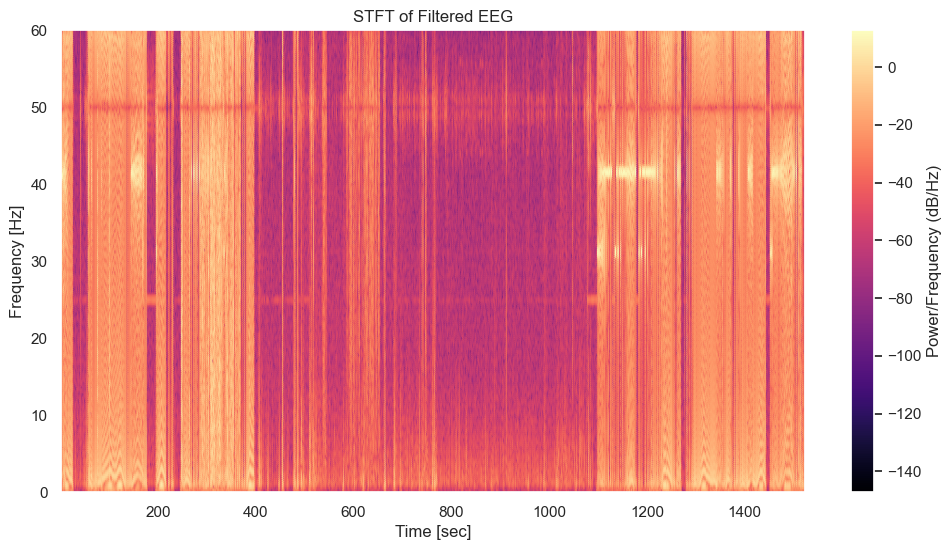

In [ ]:
# 创建3D图
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 创建网格
T, F = np.meshgrid(t_spec, f_spec)

# 绘制3D表面
surf = ax.plot_surface(T, F, 10 * np.log10(Sxx), 
                      cmap='viridis',
                      linewidth=0,
                      antialiased=True)

# 设置标签
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')
ax.set_zlabel('Amplitude [dB]')
ax.set_title('3D Time-Frequency Analysis')

# 添加颜色条
fig.colorbar(surf, ax=ax, label='Intensity [dB]')

# 调整视角，让坐标轴在右下角交汇
ax.view_init(elev=20, azim=225)  # 调整这两个参数

plt.show()

In [ ]:
import numpy as np
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

eeg_signal = df_chan1['EEG_filtered'].values  # Filtered EEG data
t_original = df_chan1['Timestamp'].values  
fs = 125  # Sampling frequency in Hz
N = len(eeg_signal)  # Total samples

# STFT parameters (matching your settings)
nperseg = 256    # Window length: 256 samples (~2.048 sec at 125Hz)
noverlap = 128   # 50% overlap (128 samples)
nfft = 512       # FFT points (optional for frequency interpolation)

# Theoretical segment calculation
hop_size = nperseg - noverlap  # 128 samples advance
num_segments = (N - nperseg) // hop_size + 1

# --- Results Verification ---
print(f"Original signal duration: {t_original[-1]:.2f} sec ({N} samples)")
print(f"STFT time axis duration: {len(t_stft)}")
print(f"Theoretical STFT time axis duration:{num_segments}")


Original signal duration: 2471.02 sec (190469 samples)
STFT time axis duration: 1487
Theoretical STFT time axis duration:1487


STFT works by breaking the signal into short time segments and performing the Fourier Transform on each one. But we can’t just “cut” the signal into pieces without causing problems. If we simply chop the signal at hard edges (like slicing bread), we introduce artificial discontinuities—sharp jumps at the start and end of each segment. This creates frequency artifacts in the Fourier Transform (e.g., spectral leakage).
So we need to apply windows to all segements. And we can try different types of window.

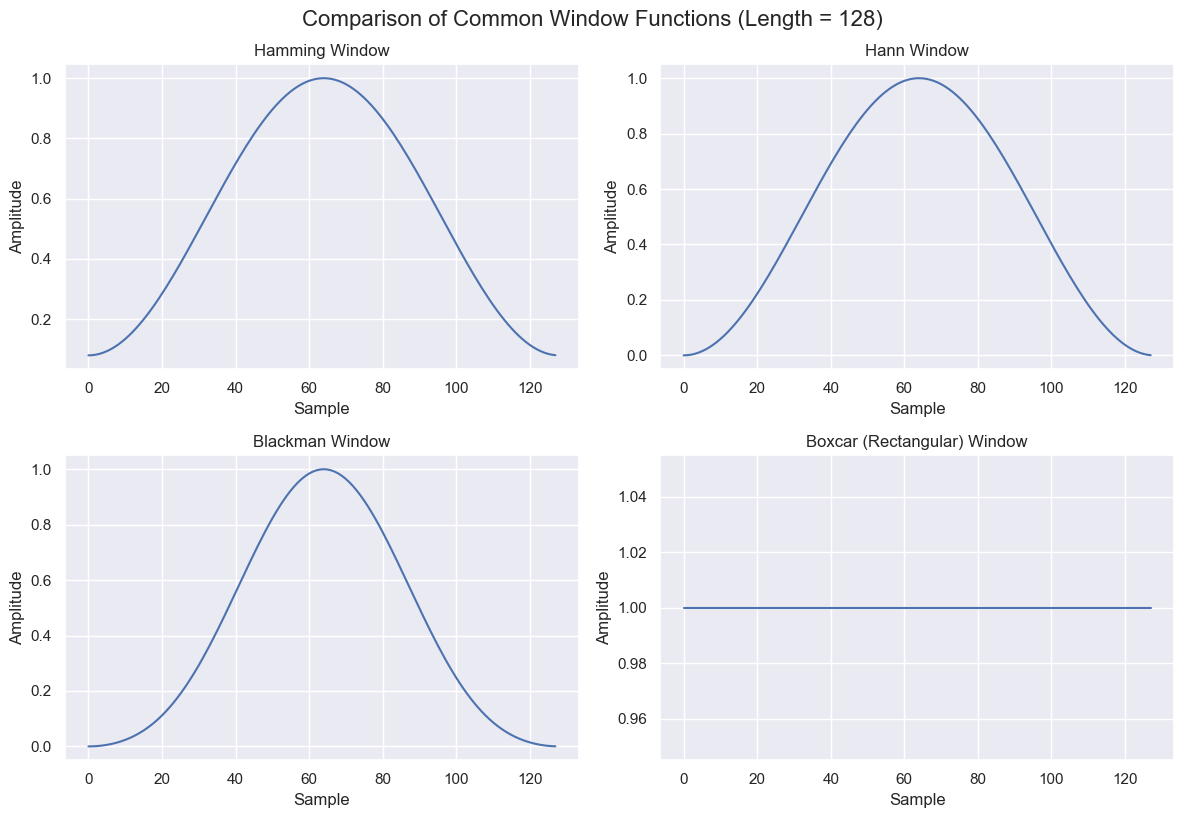

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

# Define window parameters
window_length = 128
window_types = ['hamming', 'hann', 'blackman', 'boxcar']
titles = ['Hamming', 'Hann', 'Blackman', 'Boxcar (Rectangular)']

# Create figure
plt.figure(figsize=(12, 8))

# Plot each window
for i, win_type in enumerate(window_types):
    window = get_window(win_type, window_length)
    plt.subplot(2, 2, i + 1)
    plt.plot(window)
    plt.title(f'{titles[i]} Window')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.suptitle('Comparison of Common Window Functions (Length = 128)', fontsize=16, y=1.02)
plt.show()


- Hamming and Hann are good compromises and often default choices for EEG or general signals.

- Blackman is ideal when we need very clean frequency separation but can tolerate lower time resolution.

- Boxcar should only be used when we care most about keeping raw temporal shape and not frequency cleanliness (e.g., for detecting sharp events, but not their frequency content).

C:\Users\18045\AppData\Local\Temp\ipykernel_2300\3939412346.py:29: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t_stft, f_stft, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')


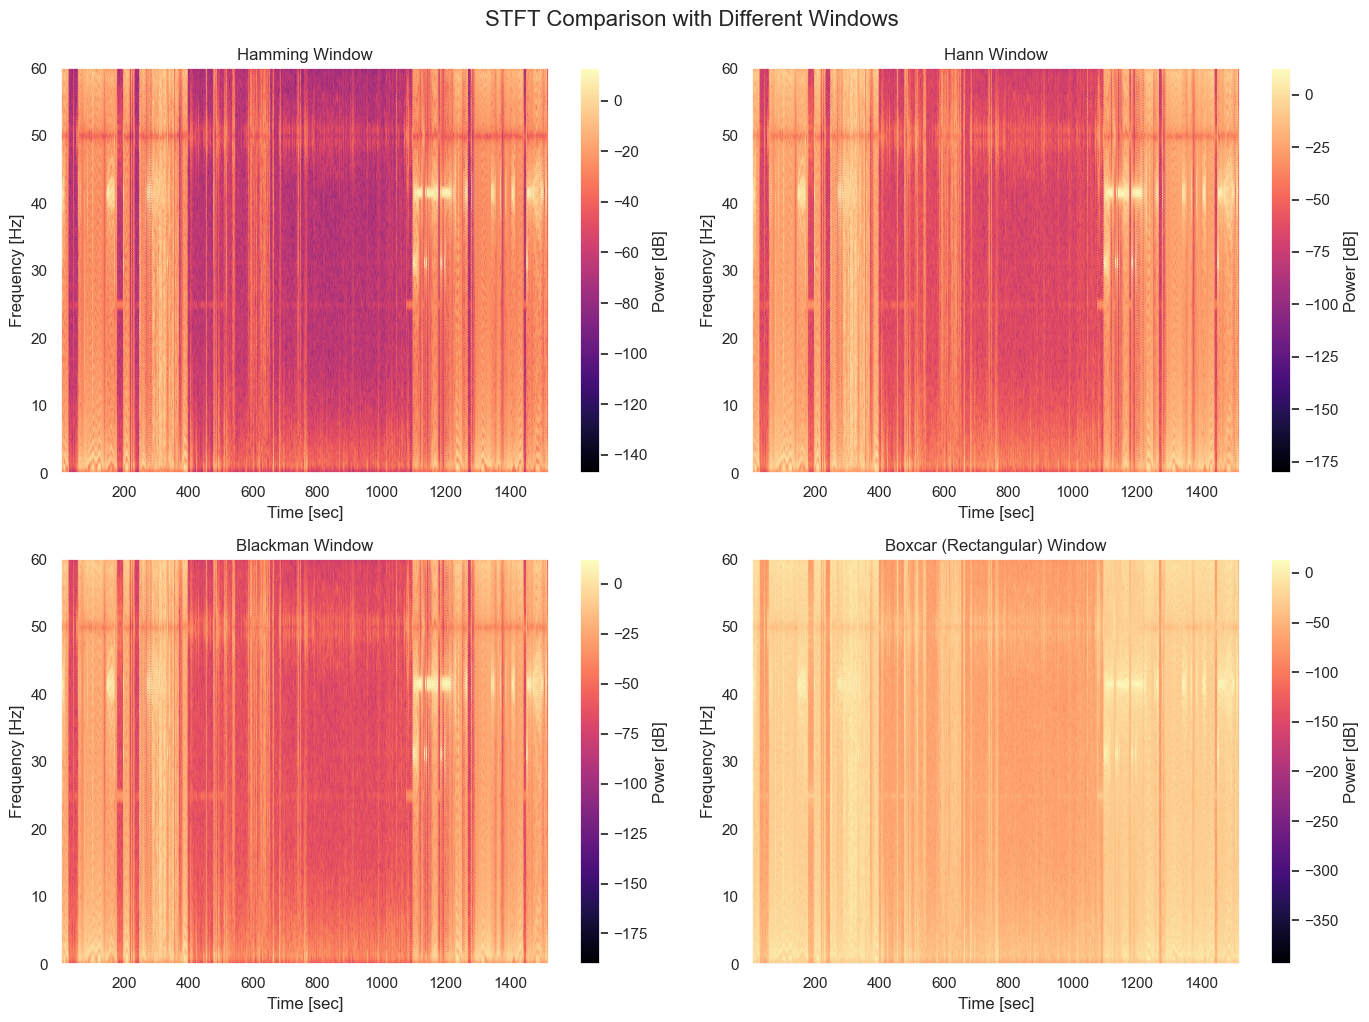

In [ ]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
import numpy as np

# Parameters
fs = 125.0
nperseg = 256
noverlap = 128
nfft = 512

# List of window types to compare
windows = ['hamming', 'hann', 'blackman', 'boxcar']
titles = ['Hamming Window', 'Hann Window', 'Blackman Window', 'Boxcar (Rectangular) Window']

# Create subplot
plt.figure(figsize=(14, 10))

for i, win in enumerate(windows):
    f_stft, t_stft, Sxx = spectrogram(
        df_chan1['EEG_filtered'].values,
        fs=fs,
        window=win,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft
    )
    
    plt.subplot(2, 2, i + 1)
    plt.pcolormesh(t_stft, f_stft, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')
    plt.colorbar(label='Power [dB]')
    plt.ylim(0, 60)
    plt.title(titles[i])
    plt.xlabel('Time [sec]')
    plt.ylabel('Frequency [Hz]')

plt.tight_layout()
plt.suptitle('STFT Comparison with Different Windows', fontsize=16, y=1.02)
plt.show()


Now we have tried different window functions, but we have no idea about how the length of window (nperseg) would influence the output. Let us try different window length.

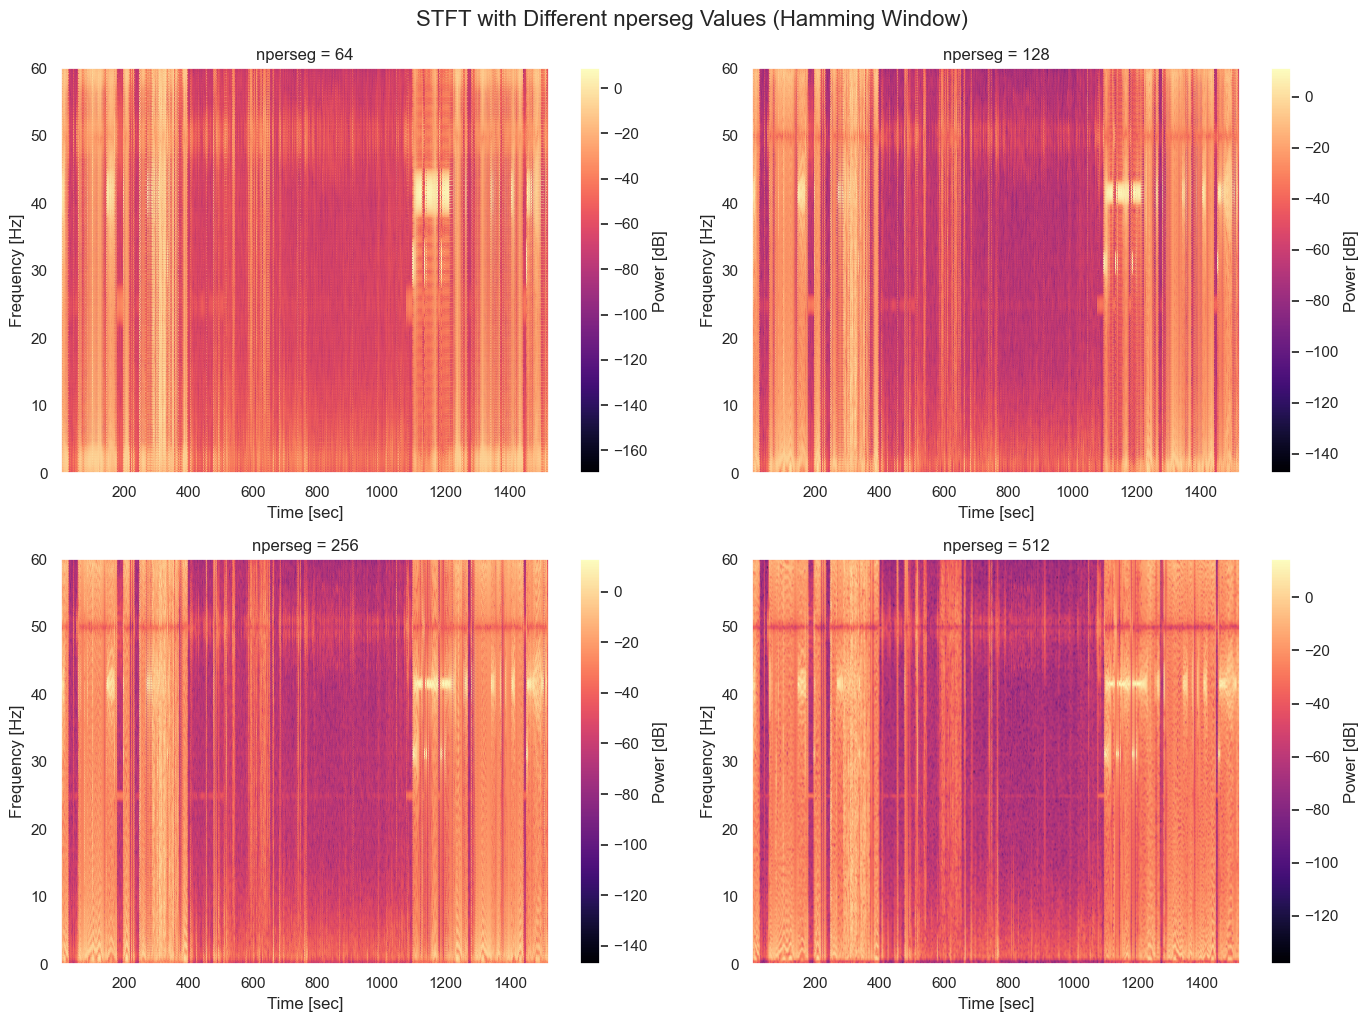

In [ ]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
import numpy as np

# Parameters
fs = 125.0
noverlap = 128
nfft = 512
nperseg_values = [64, 128, 256, 512]
titles = [f'nperseg = {n}' for n in nperseg_values]

# Create 2x2 subplot
plt.figure(figsize=(14, 10))

for i, nperseg in enumerate(nperseg_values):
    f_stft, t_stft, Sxx = spectrogram(
        df_chan1['EEG_filtered'].values,
        fs=fs,
        window='hamming',
        nperseg=nperseg,
        noverlap=min(noverlap, nperseg // 2),  # ensure valid overlap
        nfft=nfft
    )

    plt.subplot(2, 2, i + 1)
    plt.pcolormesh(t_stft, f_stft, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')
    plt.colorbar(label='Power [dB]')
    plt.ylim(0, 60)
    plt.title(titles[i])
    plt.xlabel('Time [sec]')
    plt.ylabel('Frequency [Hz]')

plt.tight_layout()
plt.suptitle('STFT with Different nperseg Values (Hamming Window)', fontsize=16, y=1.02)
plt.show()


##  EEG Frequency Band Power Analysis
After playing with different windows and parameters, now we can compare band power across different time segments.

## Setup

| Time Segment | Time Range (sec) | Duration (min)   | Description              |
|--------------|------------------|------------------|--------------------------|
| **T1**       | 0 – 900          | 0 – 15 minutes   | Early phase              |
| **T2**       | 900 – 1500       | 15 – 25 minutes  | Middle phase             |
| **T3**       | 1500 – ~2471     | 25 – 41.2 minutes| Late phase (STFT limited)|

| Frequency Band | Frequency Range (Hz) | Description                   |
|----------------|----------------------|-------------------------------|
| **Band A**     | 1 – 4 Hz             | Delta (low-frequency band)    |
| **Band B**     | 22 – 28 Hz           | High Beta / Low Gamma         |
| **Band C**     | 38 – 44 Hz           | Mid Gamma (cognitive-related) |


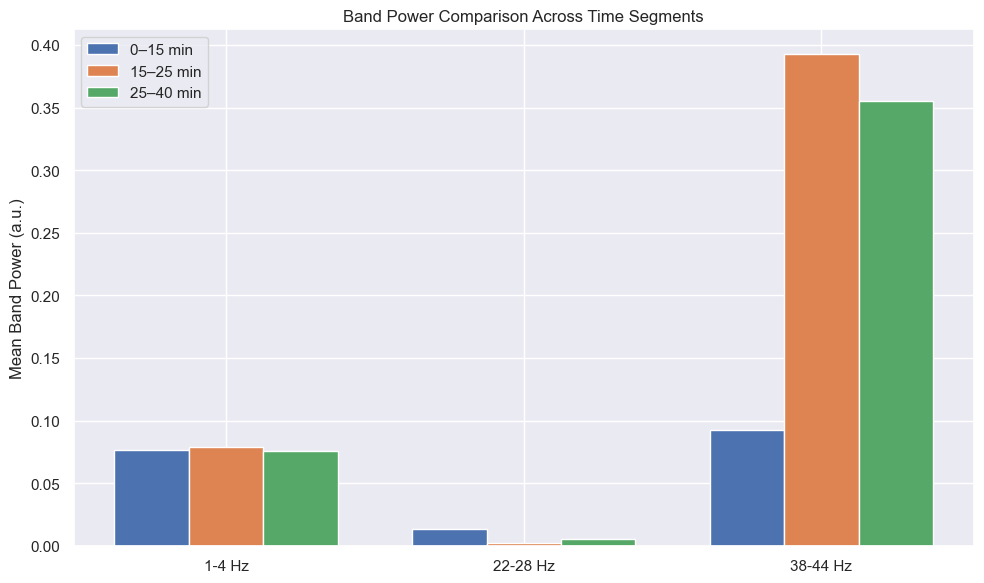

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# --- Parameters ---
fs = 125
eeg_signal = df_chan1['EEG_filtered'].values
t_original = df_chan1['Timestamp'].values
nperseg = 256
noverlap = 128
nfft = 512

# --- Compute STFT ---
f_stft, t_stft, Sxx = spectrogram(
    eeg_signal, fs=fs, window='hamming', nperseg=nperseg,
    noverlap=noverlap, nfft=nfft
)

# --- Time masks in seconds ---
mask_T1 = (t_stft >= 0) & (t_stft < 900)       # 0–15 min
mask_T2 = (t_stft >= 900) & (t_stft < 1500)    # 15–25 min
mask_T3 = (t_stft >= 1500)                     # 25 min onward (auto-truncate)

# --- Frequency masks in Hz ---
mask_band_A = (f_stft >= 1) & (f_stft <= 4)
mask_band_B = (f_stft >= 22) & (f_stft <= 28)
mask_band_C = (f_stft >= 38) & (f_stft <= 44)

# --- Power computation ---
def compute_band_power(Sxx, f_mask, t_mask):
    return np.mean(Sxx[f_mask][:, t_mask])

# Time × Band matrix
power_T1 = [
    compute_band_power(Sxx, mask_band_A, mask_T1),
    compute_band_power(Sxx, mask_band_B, mask_T1),
    compute_band_power(Sxx, mask_band_C, mask_T1),
]
power_T2 = [
    compute_band_power(Sxx, mask_band_A, mask_T2),
    compute_band_power(Sxx, mask_band_B, mask_T2),
    compute_band_power(Sxx, mask_band_C, mask_T2),
]
power_T3 = [
    compute_band_power(Sxx, mask_band_A, mask_T3),
    compute_band_power(Sxx, mask_band_B, mask_T3),
    compute_band_power(Sxx, mask_band_C, mask_T3),
]

# --- Bar Plot ---
labels = ['1-4 Hz', '22-28 Hz', '38-44 Hz']
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, power_T1, width, label='0–15 min')
plt.bar(x,        power_T2, width, label='15–25 min')
plt.bar(x + width, power_T3, width, label='25–40 min')

plt.xticks(x, labels)
plt.ylabel('Mean Band Power (a.u.)')
plt.title('Band Power Comparison Across Time Segments')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Wavelet

Let’s now take a look at the wavelet transform. Unlike the Fourier transform, which only uses frequency (ω) as a variable, the wavelet transform involves two key parameters: scale (a) and translation (τ). The scale controls the stretching or compression of the wavelet function, and the translation controls its shifting across time.

This has important implications. Just like in physics where we cannot simultaneously determine both the momentum and position of a particle, in signal analysis, we also cannot determine both the exact frequency and the exact time a component appears. What we can determine is the presence of a frequency component within a time interval, not at a specific instant. This is why the concept of “instantaneous frequency” in an absolute sense does not really exist.


In [ ]:
Image(url="stft-1.jpg", width=300, height=300)
Image(url="stft-2.jpg", width=300, height=300)

When dealing with time-varying, non-stationary signals, high frequencies are best analyzed with shorter windows, and low frequencies with longer windows. However, in the Short-Time Fourier Transform (STFT), the window size is fixed — it does not adapt to the signal. This fixed window makes STFT less ideal for analyzing signals whose frequency characteristics change over time.

Wavelet transform was developed to solve this problem. Instead of using a fixed window like STFT, wavelet transform replaces the concept of windowing altogether. More importantly, it also abandons the infinite-length sine and cosine basis functions used in Fourier analysis. Instead, it uses finite-length, decaying wavelets as the basis. Here is the equation:
$$
WT(a, \tau) = \frac{1}{\sqrt{a}} \int_{-\infty}^{\infty} f(t) \cdot \psi\left(\frac{t - \tau}{a}\right) dt
$$


These wavelets can stretch and shift — a narrow wavelet corresponds to high frequencies, while a wide wavelet corresponds to low frequencies. As the wavelet slides (translates) across the signal, it gets multiplied with the signal. When the wavelet and a part of the signal match well at a certain scale and position, the multiplication result is large. This tells us that a certain frequency component is present at a specific time in the signal.

Therefore, wavelet transform not only tells us what frequencies are present, but also when they are present. By sweeping across the signal at all scales and positions, we obtain a full time-frequency representation of the signal.

With wavelet transform, we are no longer limited by the constraints of STFT, and we can finally perform effective time-frequency analysis on non-stationary signals!

In [ ]:
Image(url="wavelet.jpg", width=300, height=300) 

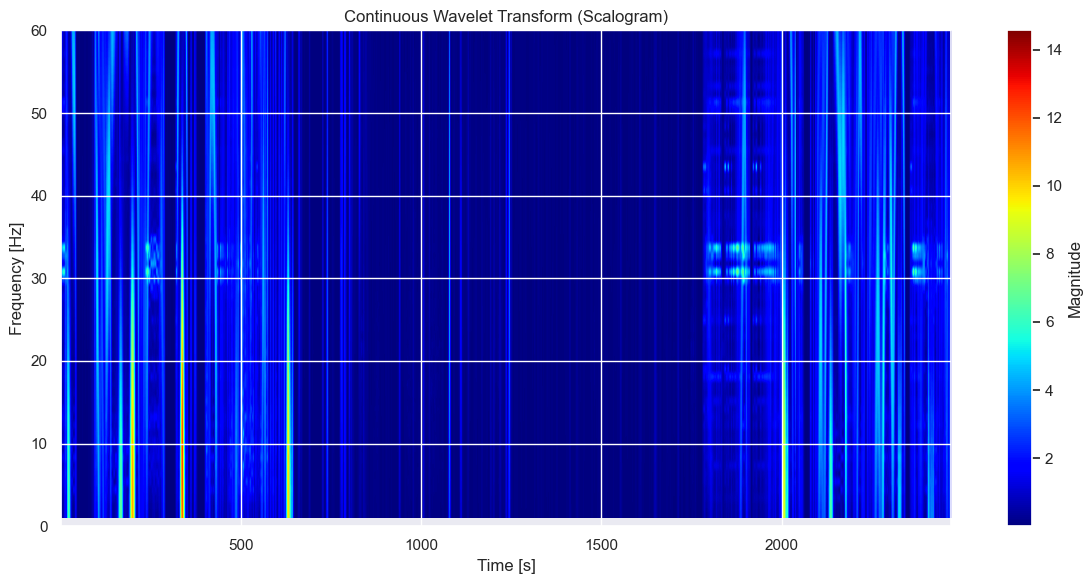

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 原始参数
fs = 125
signal = df_chan1['EEG_filtered'].values
t = df_chan1['Timestamp'].values

# 选择小波函数（Morlet 是经典选择）
wavelet = 'cmor1.5-1.0'  # Complex Morlet (可选：'morl', 'cmor', 'mexh')

# 设置 scale 范围（控制频率范围）
scales = np.arange(1, 128)  # 更多 scale → 更宽频率范围

# 连续小波变换
coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=1/fs)

# 可视化 scalogram
plt.figure(figsize=(12, 6))
plt.imshow(np.abs(coefficients), extent=[t[0], t[-1], frequencies[-1], frequencies[0]],
           cmap='jet', aspect='auto')
plt.colorbar(label='Magnitude')
plt.title('Continuous Wavelet Transform (Scalogram)')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.ylim(0, 60)  # 可根据你关心的频段裁剪
plt.tight_layout()
plt.show()


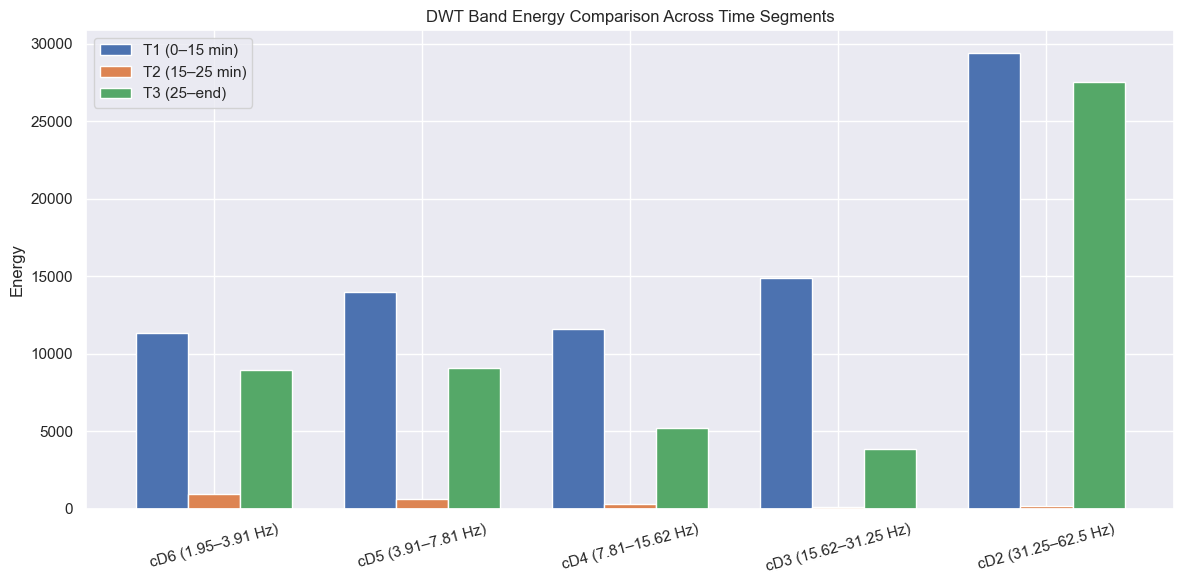

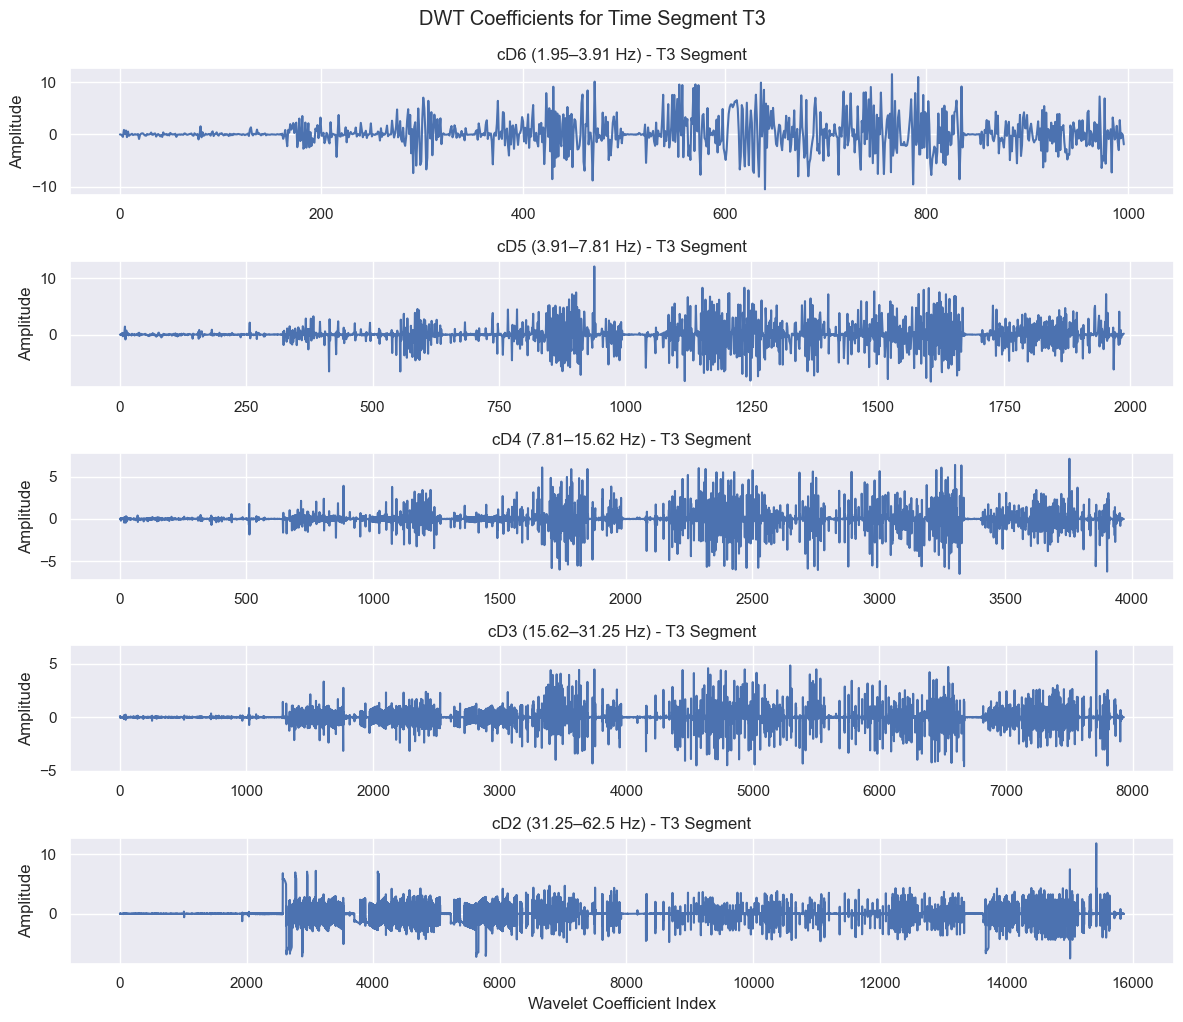

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Parameters
fs = 125  # Sampling frequency
signal = df_chan1['EEG_filtered'].values
timestamps = df_chan1['Timestamp'].values

# Define time segments (in seconds)
segments = {
    'T1 (0–15 min)': (0, 900),
    'T2 (15–25 min)': (900, 1500),
    'T3 (25–end)': (1500, timestamps[-1])
}

# DWT settings
wavelet = 'db4'
level = 6  # 6-level decomposition

# Frequency bands associated with DWT levels for fs=125Hz
dwt_bands = {
    'cD6 (1.95–3.91 Hz)': [],
    'cD5 (3.91–7.81 Hz)': [],
    'cD4 (7.81–15.62 Hz)': [],
    'cD3 (15.62–31.25 Hz)': [],
    'cD2 (31.25–62.5 Hz)': []
}

# Energy storage by segment and band
energy_results = {segment: [] for segment in segments}

# Process each segment
for label, (start_sec, end_sec) in segments.items():
    mask = (timestamps >= start_sec) & (timestamps < end_sec)
    segment_signal = signal[mask]

    # DWT decomposition
    coeffs = pywt.wavedec(segment_signal, wavelet, level=level)
    cD = coeffs[1:]  # Exclude cA6

    # Compute energy of each band
    for i, band in enumerate(dwt_bands.keys()):
        energy = np.sum(np.square(cD[i]))
        dwt_bands[band].append(cD[i])  # Save for visualization
        energy_results[label].append(energy)

# Plot DWT band energy comparison
labels = list(dwt_bands.keys())
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12, 6))
for i, (seg_label, energies) in enumerate(energy_results.items()):
    plt.bar(x + (i - 1) * width, energies, width, label=seg_label)

plt.xticks(x, labels, rotation=15)
plt.ylabel('Energy')
plt.title('DWT Band Energy Comparison Across Time Segments')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualize DWT coefficients for last segment (T3) as example
plt.figure(figsize=(12, 10))
for i, (band_name, coeff_list) in enumerate(dwt_bands.items(), 1):
    coeff = coeff_list[2]  # T3 segment is index 2
    plt.subplot(len(dwt_bands), 1, i)
    plt.plot(coeff)
    plt.title(f'{band_name} - T3 Segment')
    plt.ylabel('Amplitude')

plt.xlabel('Wavelet Coefficient Index')
plt.tight_layout()
plt.suptitle('DWT Coefficients for Time Segment T3', y=1.02)
plt.show()


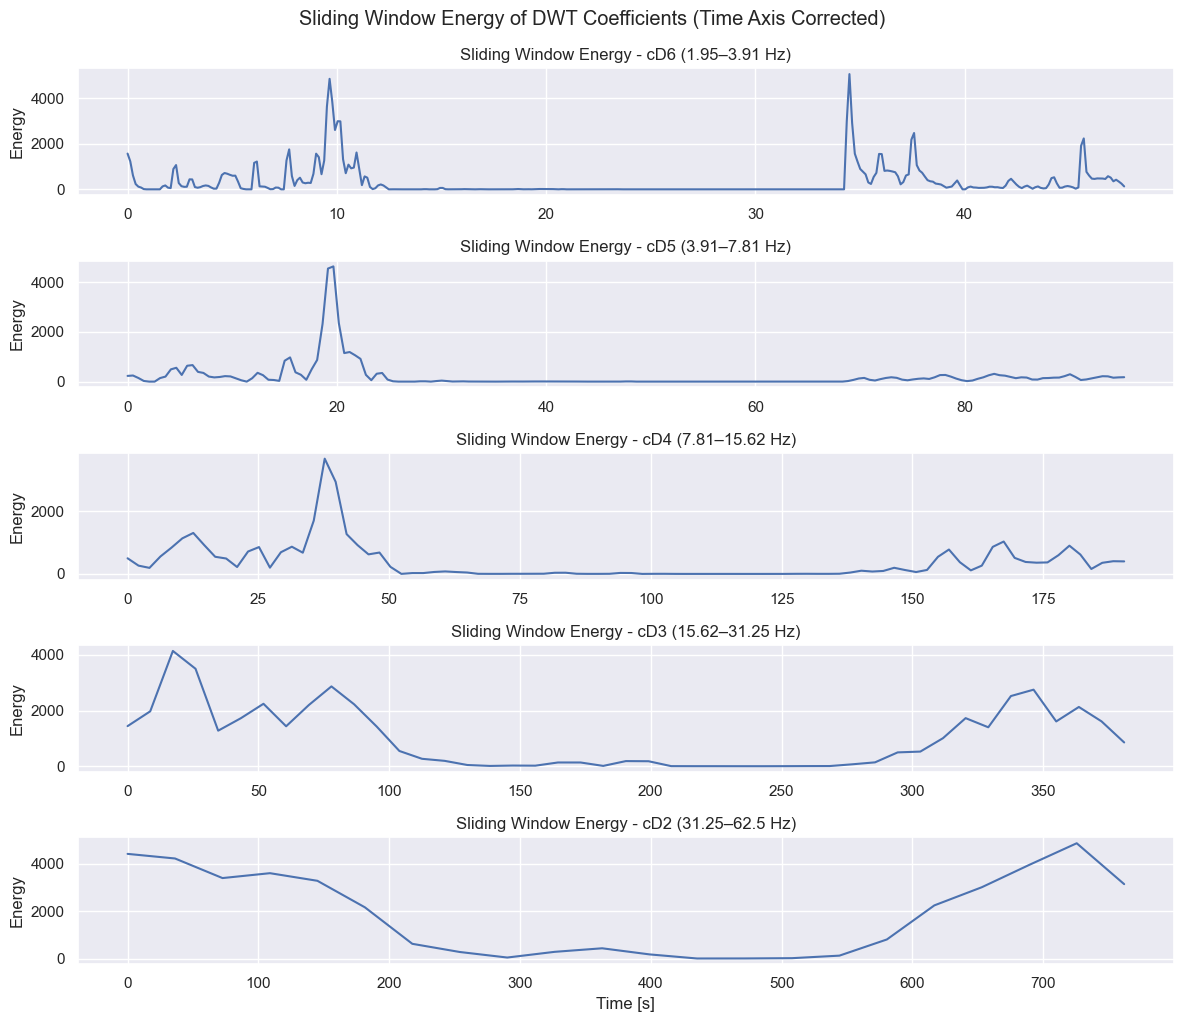

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Parameters
fs = 125
signal = df_chan1['EEG_filtered'].values
wavelet = 'db4'
level = 6
signal_len = len(signal)

# Perform DWT
coeffs = pywt.wavedec(signal, wavelet, level=level)
cD_all = coeffs[1:]  # cD6 ~ cD1

# DWT bands and labels (fs = 125 Hz)
dwt_labels = [
    'cD6 (1.95–3.91 Hz)',
    'cD5 (3.91–7.81 Hz)',
    'cD4 (7.81–15.62 Hz)',
    'cD3 (15.62–31.25 Hz)',
    'cD2 (31.25–62.5 Hz)'
]

# Sliding window energy calculation
window_size = 256
step_size = 128

def sliding_energy(coeff, win_size, step):
    return [
        np.sum(coeff[i:i+win_size]**2)
        for i in range(0, len(coeff) - win_size, step)
    ]

# Plot energy curves with time axis correction
plt.figure(figsize=(12, 10))
for i, (coeff, label) in enumerate(zip(cD_all[::-1][1:6], dwt_labels), 1):  # Use cD6 to cD2
    energy_curve = sliding_energy(coeff, window_size, step_size)
    scale = 2 ** (level - i)  # time decimation factor per layer
    coeff_duration_sec = signal_len / fs / scale
    time_axis = np.linspace(0, coeff_duration_sec, len(energy_curve))

    plt.subplot(5, 1, i)
    plt.plot(time_axis, energy_curve)
    plt.title(f'Sliding Window Energy - {label}')
    plt.ylabel('Energy')
    plt.grid(True)

plt.xlabel('Time [s]')
plt.tight_layout()
plt.suptitle('Sliding Window Energy of DWT Coefficients (Time Axis Corrected)', y=1.02)
plt.show()


## For ticktock

In [73]:
df_orig2 = pd.read_csv('BrainFlow-RAW_08-part2_0.csv', sep='\t', header=None)
df_orig2 = df_orig2.iloc[:, :17]
df_orig2.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.0,-8842.953604,-5133.905129,-38132.456020,-30874.397561,-27210.276092,-6800.495899,-77534.044091,-14300.489640,-7030.025963,-5249.798924,-19520.158412,-31332.228343,-17046.624964,-216.431942,-23881.430791,-93750.011176
1,2.0,-16513.804080,-10749.400943,-76633.849935,-61568.237730,-50829.923252,-10593.139898,-151201.616371,-26310.976006,-20975.927529,-8495.808660,-42218.466666,-63119.180574,-41765.665026,-3566.623159,-47615.652992,-187500.022352
2,4.0,-14939.615421,-10525.704685,-77065.283306,-62312.595524,-52065.482982,-10102.005017,-148811.678447,-25576.654145,-17915.884306,-7290.312027,-39361.153765,-63003.286779,-36484.059570,1961.499686,-40615.243091,-187500.022352
3,6.0,-17560.692735,-10448.099428,-76288.448428,-61561.375745,-53252.472371,-12863.116010,-154376.748726,-28100.456667,-20135.077254,-8543.529635,-41720.469799,-63513.040663,-40618.774667,-2052.739507,-46206.397856,-187500.022352
4,8.0,-14481.158791,-10829.107264,-77106.388164,-62020.860555,-50121.775284,-8921.028247,-147761.481733,-24798.835790,-19617.991998,-7721.253660,-40772.688779,-62801.718748,-39231.692461,-1087.725292,-44136.626319,-187500.022352


In [75]:
df_orig2.columns = ['Time', 'EEG1', 'EEG2', 'EEG3', 'EEG4', 'EEG5', 'EEG6', 'EEG7', 'EEG8', 'EEG9', 'EEG10', 'EEG11', 'EEG12', 'EEG13', 'EEG14', 'EEG15', 'EEG16']
df_orig2

,Time,EEG1,EEG2,EEG3,EEG4,EEG5,EEG6,EEG7,EEG8,EEG9,EEG10,EEG11,EEG12,EEG13,EEG14,EEG15,EEG16
0,0.0,-8842.953604,-5133.905129,-38132.456020,-30874.397561,-27210.276092,-6800.495899,-77534.044091,-14300.489640,-7030.025963,-5249.798924,-19520.158412,-31332.228343,-17046.624964,-216.431942,-23881.430791,-93750.011176
1,2.0,-16513.804080,-10749.400943,-76633.849935,-61568.237730,-50829.923252,-10593.139898,-151201.616371,-26310.976006,-20975.927529,-8495.808660,-42218.466666,-63119.180574,-41765.665026,-3566.623159,-47615.652992,-187500.022352
2,4.0,-14939.615421,-10525.704685,-77065.283306,-62312.595524,-52065.482982,-10102.005017,-148811.678447,-25576.654145,-17915.884306,-7290.312027,-39361.153765,-63003.286779,-36484.059570,1961.499686,-40615.243091,-187500.022352
3,6.0,-17560.692735,-10448.099428,-76288.448428,-61561.375745,-53252.472371,-12863.116010,-154376.748726,-28100.456667,-20135.077254,-8543.529635,-41720.469799,-63513.040663,-40618.774667,-2052.739507,-46206.397856,-187500.022352
4,8.0,-14481.158791,-10829.107264,-77106.388164,-62020.860555,-50121.775284,-8921.028247,-147761.481733,-24798.835790,-19617.991998,-7721.253660,-40772.688779,-62801.718748,-39231.692461,-1087.725292,-44136.626319,-187500.022352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306319,148.0,19445.078903,-24205.016995,-82310.321308,-68801.038718,-48662.988682,-13774.821314,-82487.995325,-19494.789183,-27591.708611,-43007.326783,-74597.673070,-71945.191556,-31939.927571,-5017.407837,-25266.188415,-187500.022352
306320,150.0,16456.091876,-24275.715563,-81689.970993,-68286.948596,-50450.994128,-15639.247374,-86531.068269,-21102.885437,-29002.528370,-43281.135652,-75157.405455,-72551.393217,-35142.664330,-8298.420405,-30848.983627,-187500.022352
306321,152.0,18383.192227,-24521.517697,-81914.874246,-68226.308313,-46866.534277,-12565.815457,-80861.280067,-18657.649297,-28780.173216,-43030.796114,-74512.267055,-71882.360802,-33626.076117,-6714.732255,-27677.829883,-187500.022352
306322,154.0,18412.987103,-24042.720979,-82187.319659,-68840.154271,-50858.712299,-15625.255182,-85915.009488,-20945.149177,-27792.896663,-43158.022244,-74995.243549,-72344.326656,-32860.618277,-5988.702892,-27207.459773,-187500.022352


In [77]:
df_orig2['Timestamp'] = df_orig.index * (1 / 125)

# Switch the position of the 1st and last columns
cols = list(df_orig2.columns)
cols[0], cols[-1] = cols[-1], cols[0]
df_orig2 = df_orig2[cols]

df_orig2

,Timestamp,EEG1,EEG2,EEG3,EEG4,EEG5,EEG6,EEG7,EEG8,EEG9,EEG10,EEG11,EEG12,EEG13,EEG14,EEG15,EEG16,Time
0,0.000,-8842.953604,-5133.905129,-38132.456020,-30874.397561,-27210.276092,-6800.495899,-77534.044091,-14300.489640,-7030.025963,-5249.798924,-19520.158412,-31332.228343,-17046.624964,-216.431942,-23881.430791,-93750.011176,0.0
1,0.008,-16513.804080,-10749.400943,-76633.849935,-61568.237730,-50829.923252,-10593.139898,-151201.616371,-26310.976006,-20975.927529,-8495.808660,-42218.466666,-63119.180574,-41765.665026,-3566.623159,-47615.652992,-187500.022352,2.0
2,0.016,-14939.615421,-10525.704685,-77065.283306,-62312.595524,-52065.482982,-10102.005017,-148811.678447,-25576.654145,-17915.884306,-7290.312027,-39361.153765,-63003.286779,-36484.059570,1961.499686,-40615.243091,-187500.022352,4.0
3,0.024,-17560.692735,-10448.099428,-76288.448428,-61561.375745,-53252.472371,-12863.116010,-154376.748726,-28100.456667,-20135.077254,-8543.529635,-41720.469799,-63513.040663,-40618.774667,-2052.739507,-46206.397856,-187500.022352,6.0
4,0.032,-14481.158791,-10829.107264,-77106.388164,-62020.860555,-50121.775284,-8921.028247,-147761.481733,-24798.835790,-19617.991998,-7721.253660,-40772.688779,-62801.718748,-39231.692461,-1087.725292,-44136.626319,-187500.022352,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306319,2450.552,19445.078903,-24205.016995,-82310.321308,-68801.038718,-48662.988682,-13774.821314,-82487.995325,-19494.789183,-27591.708611,-43007.326783,-74597.673070,-71945.191556,-31939.927571,-5017.407837,-25266.188415,-187500.022352,148.0
306320,2450.560,16456.091876,-24275.715563,-81689.970993,-68286.948596,-50450.994128,-15639.247374,-86531.068269,-21102.885437,-29002.528370,-43281.135652,-75157.405455,-72551.393217,-35142.664330,-8298.420405,-30848.983627,-187500.022352,150.0
306321,2450.568,18383.192227,-24521.517697,-81914.874246,-68226.308313,-46866.534277,-12565.815457,-80861.280067,-18657.649297,-28780.173216,-43030.796114,-74512.267055,-71882.360802,-33626.076117,-6714.732255,-27677.829883,-187500.022352,152.0
306322,2450.576,18412.987103,-24042.720979,-82187.319659,-68840.154271,-50858.712299,-15625.255182,-85915.009488,-20945.149177,-27792.896663,-43158.022244,-74995.243549,-72344.326656,-32860.618277,-5988.702892,-27207.459773,-187500.022352,154.0


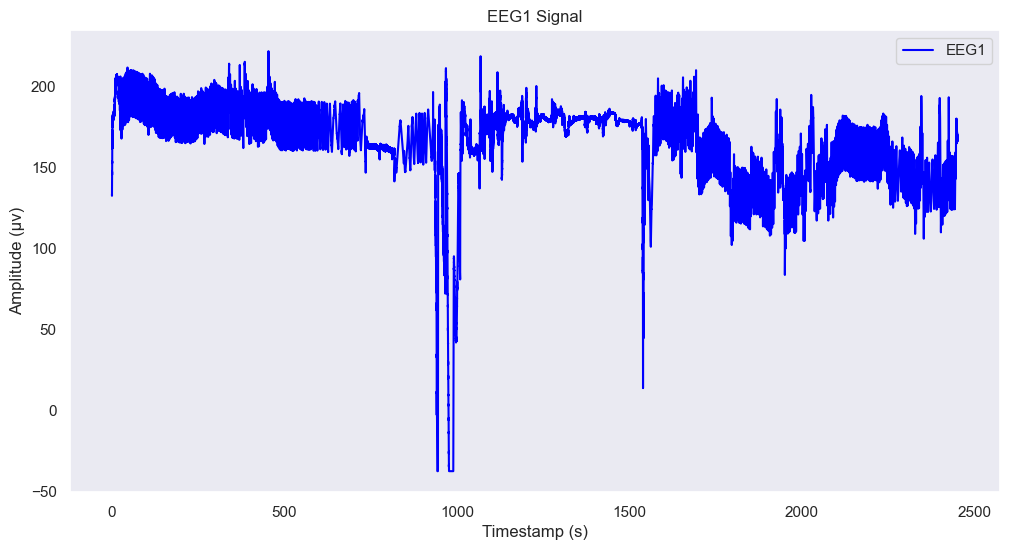

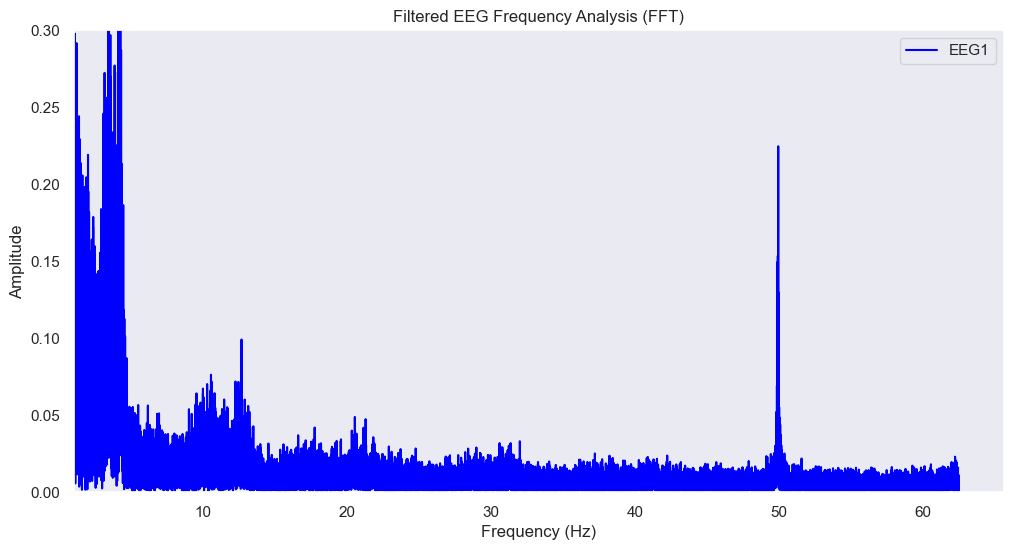

C:\Users\18045\AppData\Local\Temp\ipykernel_2300\4277920729.py:60: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t_spec + df_chan2['Timestamp'].iloc[0], f_spec, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis') # Added cmap for color scheme


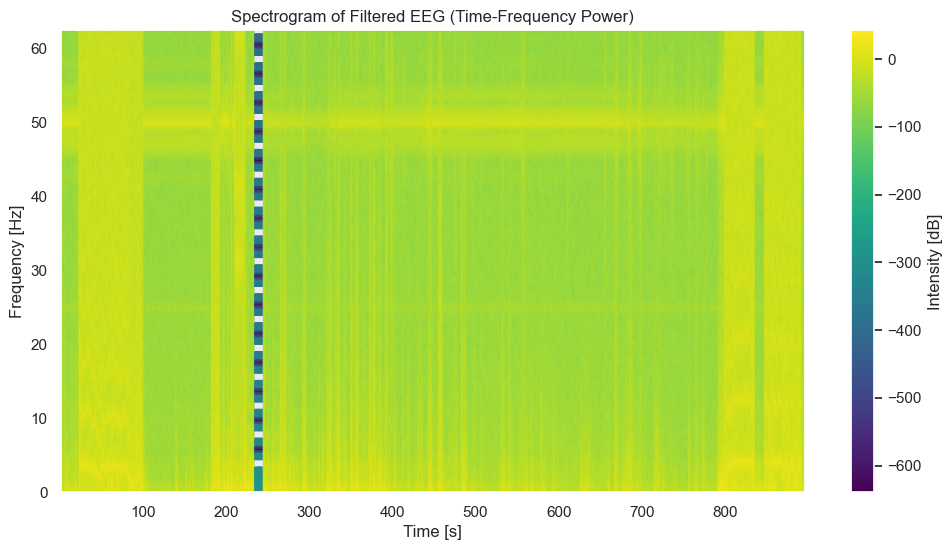

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.signal import butter, filtfilt, iirnotch, spectrogram
from scipy.fft import fft

fs = 125.0  # Sampling frequency in Hz

df_chan2 = df_orig2[['Timestamp', 'EEG1']].copy()
df_chan2.columns = ['Timestamp', 'EEG']
df_chan2['EEG'] = df_chan2['EEG']/(1000)+150

# remove the outliers with difference of 10k
df_chan2 = df_chan2[df_chan2['EEG'].diff().abs() < 10]

# plot
sns.set(style="darkgrid")
plt.figure(figsize=(12, 6))
plt.plot(df_chan2['Timestamp'], df_chan2['EEG'], label='EEG1', color='blue')
plt.title('EEG1 Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (μv)')
plt.legend()
plt.grid()
plt.show()

# --- FFT-based Frequency Analysis ---
# Calculate the FFT
# Convert the pandas Series to a NumPy array using .values
fft_result = fft(df_chan2['EEG'].values)
n = len(df_chan2['EEG']) # n is still the length of the original data
frequencies = np.fft.fftfreq(n, d=1/fs)

# Take the magnitude of the FFT and consider only the positive frequencies
magnitude_spectrum = np.abs(fft_result)[:n//2]
positive_frequencies = frequencies[:n//2]

# Plot the magnitude spectrum
plt.figure(figsize=(12, 6))

# Normalize by n/2 for amplitude spectrum
plt.plot(positive_frequencies, 2/n * magnitude_spectrum, label='EEG1', color='blue')
plt.title('Filtered EEG Frequency Analysis (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(1)
plt.ylim(0, 0.3)
plt.legend()
plt.grid()
plt.show()

# --- Time-Frequency Power Spectrum Analysis (Spectrogram) ---
# Perform time-frequency analysis using spectrogram
# Use the filtered data
f_spec, t_spec, Sxx = spectrogram(df_chan2['EEG'].values, fs=fs, nperseg=256, noverlap=128)

plt.figure(figsize=(12, 6))
# Plot the spectrogram (time-frequency power)
# Using 10*log10(Sxx) for power spectral density in dB
plt.pcolormesh(t_spec + df_chan2['Timestamp'].iloc[0], f_spec, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis') # Added cmap for color scheme
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of Filtered EEG (Time-Frequency Power)')
plt.colorbar(label='Intensity [dB]')
# Optional: Limit frequency range if needed, e.g., plt.ylim([0, 60])
plt.show()

# # Perform time-frequency analysis using spectrogram
# f, t, Sxx = spectrogram(df_chan2['EEG'], fs=125, nperseg=256, noverlap=128)
# plt.figure(figsize=(12, 6))
# plt.pcolormesh(t, f, 10 * np.log10(Sxx), cmap='plasma', shading='gouraud')  # Changed colorset to 'plasma'
# plt.ylabel('Frequency [Hz]')
# plt.xlabel('Time [s]')
# plt.title('Spectrogram of EEG1')
# plt.colorbar(label='Intensity [dB]')
# plt.show()

# # plot for frequency analysis， x-axis is frequency, y-axis is amplitude
# plt.figure(figsize=(12, 6))
# plt.plot(f, 10 * np.log10(Sxx.mean(axis=1)), label='EEG1', color='blue')
# plt.title('EEG1 Frequency Analysis')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Amplitude (dB)')
# plt.legend()
# plt.grid()
# plt.show()
